# A Proof of Learning Rate Transfer Under μP — Minimal Reproduction

This notebook reproduces the deep-linear-MLP experiment from the post **A Proof of Learning
Rate Transfer Under μP** (AISTATS 2026 Batch), following the original paper by Soufiane Hayou.

The claim under test: for a deep linear network in the **maximal-update parametrization (μP)**,
the optimal one-step learning rate has a deterministic infinite-width limit

$$\eta_\infty^{(1)}=\frac{m}{L}\,\frac{y^\top K y}{\lVert K y\rVert_2^{2}},\qquad K=\frac1d X X^\top,$$

and the finite-width optimum converges to it, $\eta_n^{(1)}-\eta_\infty^{(1)}=O_P(n^{-1/2})$.

We build a depth-$L=3$ μP linear MLP $f(x)=V^\top W_L\cdots W_1 W_0 x$ (only $W_1,\dots,W_L$
trained; $W_0,V$ frozen), take **one** full-batch gradient step, grid-search the empirical
optimal learning rate $\eta_n^{(1)}$ across widths and seeds, and compare to the closed form.
Everything uses only `torch`, `numpy`, and `matplotlib`, and reproduces the reference run to
floating-point precision.

In [1]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_printoptions(precision=6)
np.set_printoptions(precision=6, suppress=True)

## Configuration

These are exactly the settings of the reference run (μP, depth 3, float64). The data is a fixed
1-D linear-regression dataset of $m=500$ points; the same data is reused at every width because
the theorem studies width asymptotics with the data held fixed.

In [2]:
DEPTH_L          = 3
WIDTHS           = [64, 128, 256, 512, 1024]
DATA_SEED        = 123
INIT_SEEDS       = [1, 2, 3]
M, D, NOISE_STD  = 500, 1, 0.1
DTYPE            = torch.float64
NUM_GRID         = 120      # learning-rate grid points
REFINE           = True     # local refinement around the best grid point
LOCAL_REFINE_PTS = 60
ETA_MAX_MULT     = 4.0      # search interval is [0, ETA_MAX_MULT * eta_inf]

## The data

$x_i\sim\mathcal N(0,I_d)$, $w_\star\sim\mathcal N(0,d^{-1}I_d)$,
$y_i=w_\star^\top x_i+\varepsilon_i$ with $\varepsilon_i\sim\mathcal N(0,\sigma^2)$.

The exact draw order (X, then $w_\star$, then noise) from a single seeded generator is what makes
the numbers below reproducible to the last digit.

In [3]:
def make_data(m, d, noise_std, seed, dtype):
    gen = torch.Generator(device="cpu")
    gen.manual_seed(int(seed))
    X      = torch.randn(m, d, generator=gen, dtype=torch.float64)
    w_star = torch.randn(d, generator=gen, dtype=torch.float64) / (d ** 0.5)
    eps    = torch.randn(m, generator=gen, dtype=torch.float64) * noise_std
    y      = X @ w_star + eps
    return X.to(dtype), y.to(dtype), w_star.to(dtype)

## The closed-form infinite-width learning rate

$\eta_\infty^{(1)}=\dfrac{m}{L}\dfrac{y^\top K y}{\lVert Ky\rVert^2}$ with the normalized input
Gram matrix $K=\tfrac1d XX^\top$. It depends only on the data and depth — not on the width.

In [4]:
def eta_infinity_t1(X, y, L, eps=1e-12):
    m, d = X.shape
    K = (X @ X.T) / d
    Ky = K @ y
    denom = torch.dot(Ky, Ky)
    if denom <= eps:
        raise ValueError("The theorem requires Ky != 0.")
    return (m / L) * (torch.dot(y, Ky) / denom)

X, y, w_star = make_data(M, D, NOISE_STD, DATA_SEED, DTYPE)
eta_inf = float(eta_infinity_t1(X, y, DEPTH_L))
eta_min, eta_max = 0.0, ETA_MAX_MULT * eta_inf
print(f"eta_inf            = {eta_inf:.13f}")
print(f"search interval    = [{eta_min:.4f}, {eta_max:.4f}]")

eta_inf            = 0.3717628470279
search interval    = [0.0000, 1.4871]


## The μP deep linear MLP

$f(x)=V^\top W_L\cdots W_1 W_0 x$. μP initialization: $W_0=\mathrm{randn}(n,d)/\sqrt d$,
$W_\ell=\mathrm{randn}(n,n)/\sqrt n$, and the **μP readout** $V=\mathrm{randn}(n)/n$ (variance
$1/n^2$, *not* the standard $1/\sqrt n$). Only the hidden matrices are trained.

In [5]:
class LinearMLP(torch.nn.Module):
    def __init__(self, d, n, L, dtype=torch.float64):
        super().__init__()
        W0     = torch.randn(n, d, dtype=dtype) / math.sqrt(d)            # frozen input
        hidden = [torch.randn(n, n, dtype=dtype) / math.sqrt(n) for _ in range(L)]
        V      = torch.randn(n, dtype=dtype) / n                          # mu-P readout (frozen)
        self.W0     = torch.nn.Parameter(W0, requires_grad=False)
        self.hidden = torch.nn.ParameterList(
            [torch.nn.Parameter(W, requires_grad=True) for W in hidden])
        self.V      = torch.nn.Parameter(V, requires_grad=False)
        self._init_hidden = [W.detach().clone() for W in hidden]          # snapshot for LR resets

    def forward(self, X):
        z = X @ self.W0.T
        for W in self.hidden:
            z = z @ W.T
        return z @ self.V

    def clone_hidden_state(self):
        return [W.detach().clone() for W in self.hidden]

    def reset_hidden_state(self):
        with torch.no_grad():
            for W, src in zip(self.hidden, self._init_hidden):
                W.copy_(src)

## One-step learning-rate search

Loss $\mathcal L_n(\eta)=\frac1{2m}\sum_i(f(x_i)-y_i)^2$. Every candidate $\eta$ starts from the
**same** initialization, so the gradient is identical across the grid — we compute it once and
reuse it (forward-only) for every $\eta$. The μP update rule applies $\eta$ with no width scaling:
$W_\ell\leftarrow W_\ell^{(0)}-\eta\,\nabla_{W_\ell}\mathcal L_n^{(0)}$.

In [6]:
def full_batch_mse(model, X, y):
    pred = model(X)
    return 0.5 * torch.mean((pred - y) ** 2)

def initial_loss_and_grads(model, X, y):
    model.reset_hidden_state()
    for W in model.hidden:
        W.grad = None
    loss0 = full_batch_mse(model, X, y)
    grads = [g.detach().clone()
             for g in torch.autograd.grad(loss0, list(model.hidden))]
    return float(loss0), grads

def loss_after_step(model, X, y, init_state, grads, eta):
    with torch.no_grad():
        for W, W0, g in zip(model.hidden, init_state, grads):
            W.copy_(W0)
            W.add_(g, alpha=-eta)          # effective_lr = eta (mu-P: no width scaling)
        return float(full_batch_mse(model, X, y))

def find_optimal_eta(model, X, y, eta_min, eta_max, num_grid, refine, local_pts):
    init_state = model.clone_hidden_state()
    _l0, grads = initial_loss_and_grads(model, X, y)
    grid   = torch.linspace(eta_min, eta_max, num_grid, dtype=torch.float64).tolist()
    losses = [loss_after_step(model, X, y, init_state, grads, e) for e in grid]
    bi = int(min(range(len(losses)), key=lambda i: losses[i]))
    eta_opt, loss_opt = grid[bi], losses[bi]
    if refine and num_grid > 1:
        step   = (eta_max - eta_min) / (num_grid - 1)
        lo, hi = max(eta_min, eta_opt - step), min(eta_max, eta_opt + step)
        lg     = torch.linspace(lo, hi, local_pts, dtype=torch.float64).tolist()
        ll     = [loss_after_step(model, X, y, init_state, grads, e) for e in lg]
        li = int(min(range(len(ll)), key=lambda i: ll[i]))
        if ll[li] < loss_opt:
            eta_opt, loss_opt = lg[li], ll[li]
    model.reset_hidden_state()
    return eta_opt, loss_opt

## Sweep widths × seeds

For each width and each of three initialization seeds, estimate $\eta_n^{(1)}$, then aggregate the
mean and standard deviation over seeds. Seeding `torch.manual_seed(s)` before each model build
reproduces the reference initializations.

In [7]:
rows = []
print(f"{'width':>6} {'eta_opt mean':>14} {'std (3 seeds)':>14} {'|err|':>12} {'rel err':>9}")
for n in WIDTHS:
    etas = []
    for s in INIT_SEEDS:
        np.random.seed(s); torch.manual_seed(s)
        model = LinearMLP(D, n, DEPTH_L, DTYPE)
        eta_opt, _ = find_optimal_eta(model, X, y, eta_min, eta_max,
                                      NUM_GRID, REFINE, LOCAL_REFINE_PTS)
        etas.append(eta_opt)
    a = np.asarray(etas)
    mean, std = float(a.mean()), float(a.std(ddof=0))
    err = abs(mean - eta_inf)
    rows.append((n, mean, std, err))
    print(f"{n:>6} {mean:>14.6f} {std:>14.6f} {err:>12.6e} {err/eta_inf:>8.1%}")

widths    = np.array([r[0] for r in rows], float)
eta_means = np.array([r[1] for r in rows], float)
eta_stds  = np.array([r[2] for r in rows], float)
abs_errs  = np.array([r[3] for r in rows], float)

 width   eta_opt mean  std (3 seeds)        |err|   rel err
    64       0.397973       0.089852 2.621031e-02     7.1%


   128       0.513404       0.188477 1.416416e-01    38.1%


   256       0.413576       0.089754 4.181295e-02    11.2%


   512       0.370510       0.036985 1.253153e-03     0.3%


  1024       0.377217       0.018707 5.453863e-03     1.5%


## Figure 1 — optimal learning rate vs width

The empirical optimum (mean ± std over seeds) should tighten onto the dashed $\eta_\infty^{(1)}$
line as width grows.

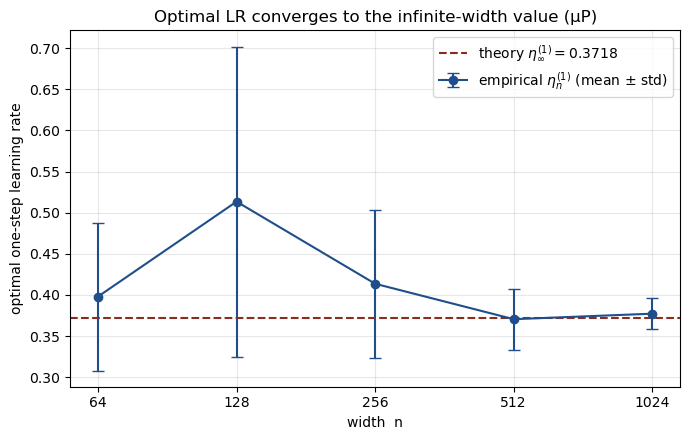

In [8]:
plt.figure(figsize=(7, 4.5))
plt.errorbar(widths, eta_means, yerr=eta_stds, marker="o", capsize=4,
             color="#1f4e8a", label=r"empirical $\eta_n^{(1)}$ (mean $\pm$ std)")
plt.axhline(eta_inf, ls="--", color="#8a2d1f",
            label=rf"theory $\eta_\infty^{{(1)}}={eta_inf:.4f}$")
plt.xscale("log", base=2)
plt.xticks(widths, [int(w) for w in widths])
plt.xlabel("width  n"); plt.ylabel(r"optimal one-step learning rate")
plt.title(r"Optimal LR converges to the infinite-width value (μP)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Figure 2 — convergence rate

Absolute error $\lvert\eta_n^{(1)}-\eta_\infty^{(1)}\rvert$ on log–log axes, against the
$n^{-1/2}$ reference the theorem predicts. We also fit the empirical log–log slope.

estimated log-log slope = -1.1350  (theory: error decays at least as fast as n^-1/2)


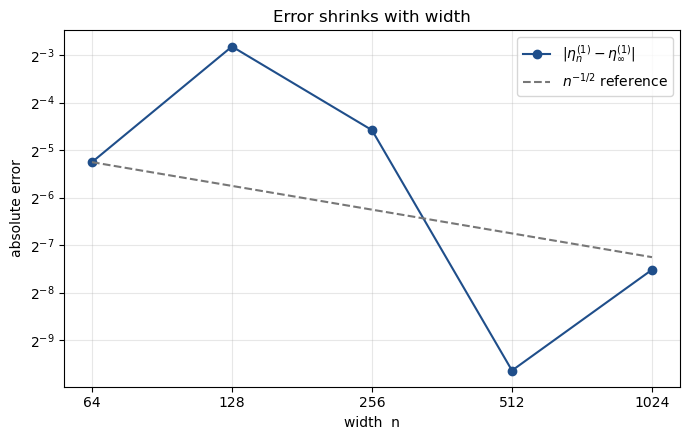

In [9]:
mask  = abs_errs > 0
slope = np.polyfit(np.log(widths[mask]), np.log(abs_errs[mask]), 1)[0]
print(f"estimated log-log slope = {slope:.4f}  (theory: error decays at least as fast as n^-1/2)")

ref = abs_errs[0] * (widths / widths[0]) ** (-0.5)   # n^-1/2 reference anchored at first point
plt.figure(figsize=(7, 4.5))
plt.loglog(widths, abs_errs, marker="o", color="#1f4e8a", base=2,
           label=r"$|\eta_n^{(1)}-\eta_\infty^{(1)}|$")
plt.loglog(widths, ref, ls="--", color="#777", base=2, label=r"$n^{-1/2}$ reference")
plt.xticks(widths, [int(w) for w in widths])
plt.xlabel("width  n"); plt.ylabel("absolute error")
plt.title("Error shrinks with width"); plt.legend(); plt.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

## Check against the reference run

The reproduced numbers should match the values reported in the post (reference run, data seed 123)
to floating-point precision.

In [10]:
reference = {
    "eta_inf":            0.3717628470278973,
    "mean_at_1024":       0.37721671018754316,
    "abs_error_at_1024":  0.005453863159645855,
    "loglog_slope":      -1.1350106932959818,
}
got = {
    "eta_inf":            eta_inf,
    "mean_at_1024":       eta_means[-1],
    "abs_error_at_1024":  abs_errs[-1],
    "loglog_slope":       slope,
}
print(f"{'quantity':>20} {'reference':>20} {'reproduced':>20} {'|diff|':>12}")
for k in reference:
    d = abs(reference[k] - got[k])
    print(f"{k:>20} {reference[k]:>20.12f} {got[k]:>20.12f} {d:>12.2e}")
assert all(abs(reference[k] - got[k]) < 1e-9 for k in reference), "mismatch vs reference!"
print("\nAll quantities match the reference run to < 1e-9. ✓")

            quantity            reference           reproduced       |diff|
             eta_inf       0.371762847028       0.371762847028     0.00e+00
        mean_at_1024       0.377216710188       0.377216710188     0.00e+00
   abs_error_at_1024       0.005453863160       0.005453863160     0.00e+00
        loglog_slope      -1.135010693296      -1.135010693296     1.11e-15

All quantities match the reference run to < 1e-9. ✓
